# Job 2: Electron Density

In [1]:
load proc/atomic_model.mat AtomFF Basis SpaceGroup Atoms hklTable

UnitCellGrid = proc.script.GridDesigner(...
    'Basis',Basis,...
    'SpaceGroup',SpaceGroup,...
    'dgrid',1/3).run();

MT = proc.script.MapTools('Grid',UnitCellGrid.PeriodicGrid,...
    'Basis',UnitCellGrid.Basis.orient,...
    'SpaceGroup',SpaceGroup,...
    'type','density',...
    'isPeriodic',true);

## 1. Calculate electron density map

In [2]:
% calculate electron density from Fobs using calculated phases
hklTable.F = hklTable.Fobs.*exp(1i*angle(hklTable.Fcalc));
hklTable.F(isnan(hklTable.F)) = hklTable.Fcalc(isnan(hklTable.F));

In [3]:
% add Friedel symmetry mates
tmp = hklTable;
tmp.F = conj(tmp.F);
tmp.h = -tmp.h;
tmp.k = -tmp.k;
tmp.l = -tmp.l;
hklTable = [hklTable;tmp];

In [4]:
% symmetry expand and compute electron density
F = MT.invert.table2array(hklTable(:,{'h','k','l','F'}),'symexpand');
rho0 = MT.inverse_fourier_transform(F);

mode = symexpand, mode2 = replace, default value = 0


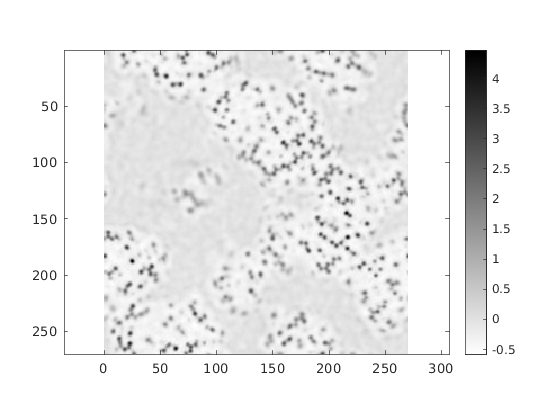

In [34]:
%[x,y,z] = MT.Grid.grid();
%[x,y,z] = MT.Basis.frac2lab(x,y,z);
imagesc(rho0(:,:,1));axis equal;colormap(flipud(gray));colorbar

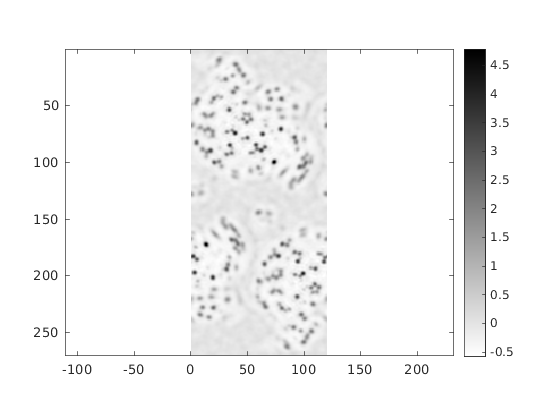

In [35]:
imagesc(squeeze(rho0(:,1,:)));axis equal;colormap(flipud(gray));colorbar

## 2. Compute masks

In [26]:
%%file blur_density.m

function rhoBlur = blur_density(MT,rho,Badd)
[F,MTf] = MT.fourier_transform(rho);
[sx,sy,sz] = MTf.Grid.grid();
[sx,sy,sz] = MTf.Basis.frac2lab(sx,sy,sz);
Fblur = latt.Blob(1,0).addB(Badd).scatteringAmplitude(sx,sy,sz);
rhoBlur = MT.inverse_fourier_transform(F.*Fblur);
end

Created file '/nfs/chess/user/spm82/mdx/mac1_20251105_goodvibes/blur_density.m'.


In [27]:
A = Atoms;
A.mdxAltGroup = true(size(Atoms,1),1);

BSM = proc.script.BulkSolventMask(...
    'LatticeGrid',latt.LatticeGrid(MT.Grid,MT.Basis),...
    'Atoms',A,...
    'SpaceGroup',SpaceGroup,...
    'rMax',5);

[indMapASU,probDist] = BSM.distance_map();
indMaps = BSM.run();

%% calculate asu mask, dilate, and weight by multiplicity

is_inside = indMaps{1}>0;
is_inside = imdilate(is_inside,strel('sphere',1));
index_extended = indMapASU.*is_inside;

% compute the multiplicity of the ASU mask
Tasu = MT.array2table(double(is_inside),is_inside);
mult = MT.table2array(Tasu,'symexpand','sum');
ind = MT.frac2ind(Tasu.x,Tasu.y,Tasu.z);
Tasu.mult = 1./mult(ind);
msk_asu = MT.table2array(Tasu(:,{'x','y','z','mult'}));

% compute the solvent mask (unit cell)
tmp = mult;
tmp(isnan(tmp)) = 0;
is_solv = not(logical(tmp));
rho_avg_solv = mean(rho0(is_solv));

msk_asu_blur = blur_density(MT,msk_asu,50);

mode = symexpand, mode2 = sum, default value = 0
mode = direct, mode2 = replace, default value = 0


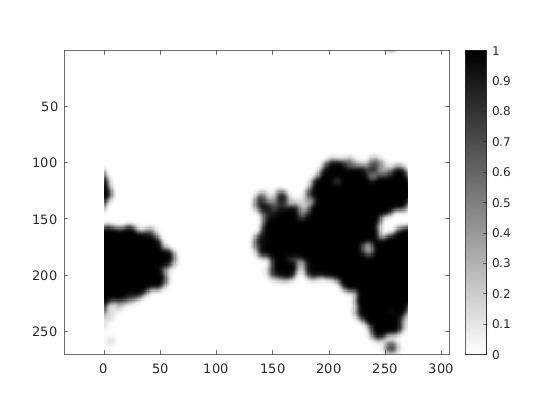

In [38]:
imagesc(msk_asu_blur(:,:,1));axis equal;colormap(flipud(gray));colorbar

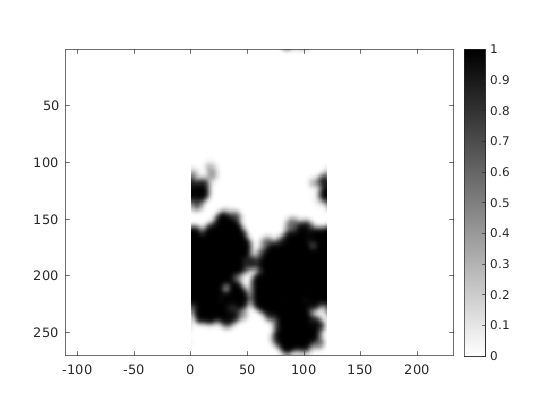

In [39]:
imagesc(squeeze(msk_asu_blur(:,1,:)));axis equal;colormap(flipud(gray));colorbar

## 3. Compute the cropped / weighted electron density of the ASU

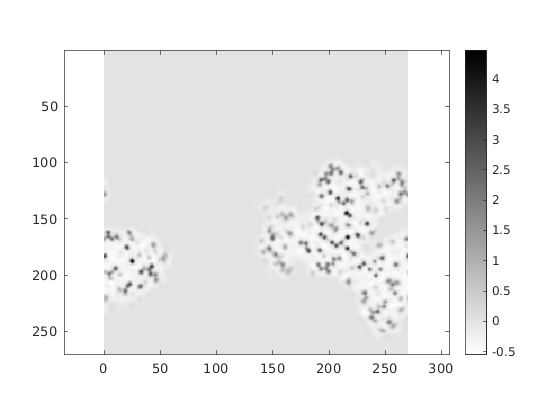

In [40]:
rho_asu = msk_asu_blur.*(rho0-rho_avg_solv);

imagesc(squeeze(rho_asu(:,:,1)));axis equal;colormap(flipud(gray));colorbar

## 4. Unwrap the ASU electron density map

In [41]:
T = MT.array2table(rho_asu,logical(indMapASU));
tmp = MT.array2table(indMapASU,logical(indMapASU));
T.atom_index = tmp.(4);

[xa,ya,za] = MT.Basis.lab2frac(A.x,A.y,A.z);
T.x = T.x - round(T.x-xa(T.atom_index));
T.y = T.y - round(T.y-ya(T.atom_index));
T.z = T.z - round(T.z-za(T.atom_index));

% make supercell grid (temporarily)
MTc = MT.resize('roi',[min(T.x),min(T.y),min(T.z)],[max(T.x),max(T.y),max(T.z)]);

rho_asu_unwrap = MTc.table2array(T);

mode = direct, mode2 = replace, default value = 0


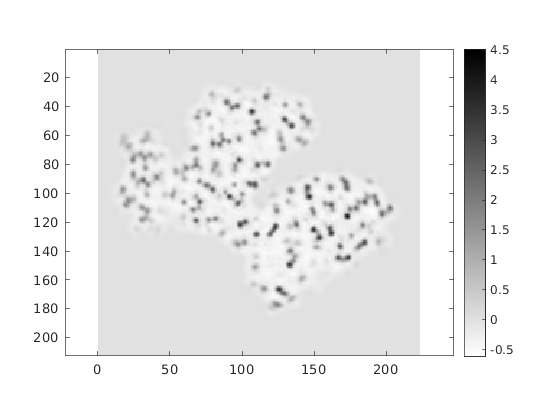

In [44]:
imagesc(squeeze(rho_asu_unwrap(:,:,85)));axis equal;colormap(flipud(gray));colorbar

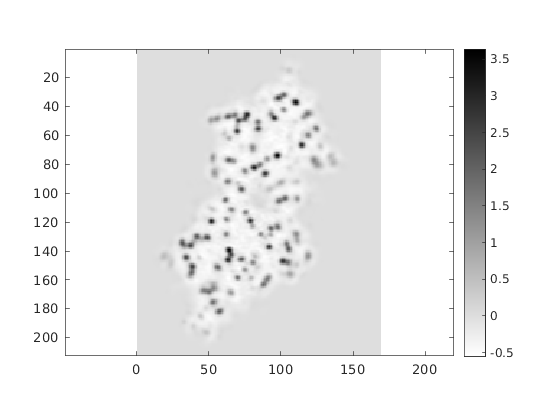

In [47]:
imagesc(squeeze(rho_asu_unwrap(:,112,:)));axis equal;colormap(flipud(gray));colorbar

## 5. Export

In [48]:
% resample on a coarser grid by Fourier cropping
[rho_asu_unwrap2,MTc2] = MTc.fourier_interpolate(rho_asu_unwrap,2/3);

%save the masked density
h5Out = 'export/mac1_edens.h5';

% save
rho = rho0;
MT.export(h5Out,'unitcell',rho,'datatype','single');

% save the unwrapped density
rho = rho_asu_unwrap;
MTc.export(h5Out,'unwrapped',rho,'newmap',true);

% save the unwrapped cropped density
rho = rho_asu_unwrap2;
MTc2.export(h5Out,'unwrapped_cropped',rho,'newmap',true);

Creating dataset in export/lys_tet_edens.h5
	Location: /maps/unitcell/rho
	Options: Columns 1 through 4

    {[270 270 120], 'Datatype', 'double', 'ChunkSize'}

  Columns 5 through 9

    {[270 270 120], 'Deflate', [1], 'datatype', 'single'}
Writing data to export/lys_tet_edens.h5
	Location: /maps/unitcell/rho
	Options: {}
> In H5D.write (line 100)
In h5write (line 175)
In io.h5/FileInterface/write (line 74)
In io.h5/MapFile/new_dataset (line 37)
In proc.script/MapTools/export (line 340)
Done.
> In proc.script/MapTools/export (line 315)
Creating dataset in export/lys_tet_edens.h5
	Location: /maps/unwrapped/rho
	Options: Columns 1 through 4

    {[212 223 169], 'Datatype', 'double', 'ChunkSize'}

  Columns 5 through 7

    {[212 223 169], 'Deflate', [1]}
Writing data to export/lys_tet_edens.h5
	Location: /maps/unwrapped/rho
	Options: {}
Done.
> In proc.script/MapTools/export (line 315)
Creating dataset in export/lys_tet_edens.h5
	Location: /maps/unwrapped_cropped/rho
	Options: Columns 1